In [ ]:
# ================================
# 1. 匯入套件
# ================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [ ]:
# 讀取資料
df_train = pd.read_csv("./cs-training.csv")
df_test = pd.read_csv("./cs-test.csv")

Validation AUC: 0.8645819390556191


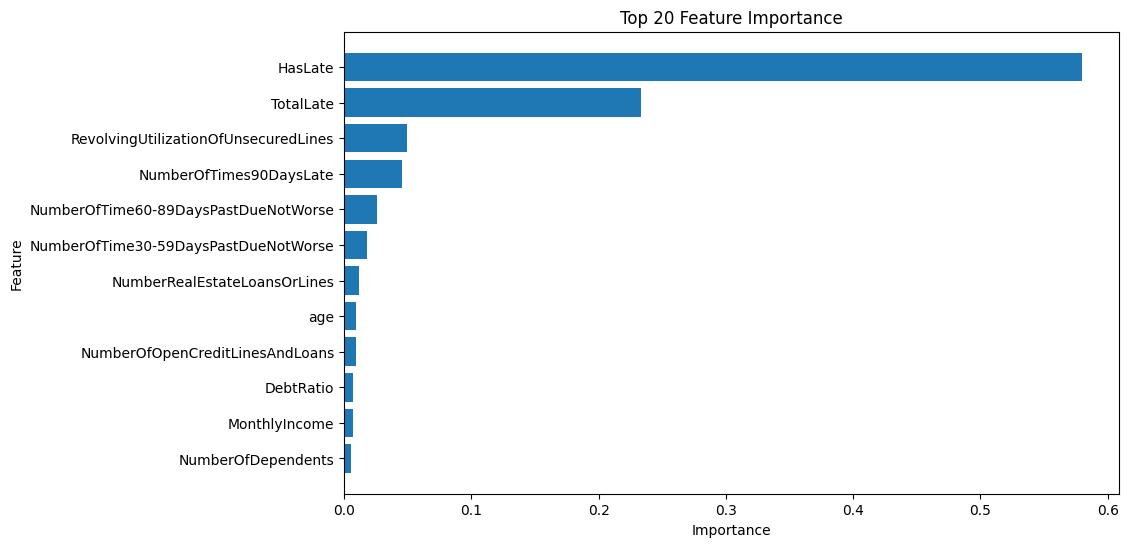

,Id,Probability
0,1,0.060773
1,2,0.057819
2,3,0.011282
3,4,0.075071
4,5,0.108632


In [ ]:
# ================================
# 3. 保留測試集 Id
# ================================

test_id = df_test["Unnamed: 0"]


# ================================
# 4. 移除訓練集中 NumberOfDependents 為空的資料列
# ================================

df_train = df_train.dropna(subset=["NumberOfDependents"])

# 保險：移除目標欄位為空的資料列
df_train = df_train.dropna(subset=["SeriousDlqin2yrs"])

print("After drop missing NumberOfDependents:", df_train.shape)

# ================================
# 5. 建立特徵工程
# ================================

def add_features(df):
    df = df.copy()

    # ----------------------------
    # A. 逾期相關特徵
    # ----------------------------

    # 總逾期次數
    df["TotalLate"] = (
        df["NumberOfTime30-59DaysPastDueNotWorse"] +
        df["NumberOfTime60-89DaysPastDueNotWorse"] +
        df["NumberOfTimes90DaysLate"]
    )

    # 是否曾經逾期
    df["HasLate"] = (df["TotalLate"] > 0).astype(int)

    # ----------------------------
    # B. 信用使用率極端值切片
    # ----------------------------

    df["RevolvingUtilizationOfUnsecuredLines"] = (
        df["RevolvingUtilizationOfUnsecuredLines"].clip(upper=4)
    )

    # ----------------------------
    # C. 收入與負債相關新特徵
    # ----------------------------

    # 1. 月收入 log
    # 目的：降低極端高收入對模型的影響
    df["MonthlyIncome_log"] = np.log1p(df["MonthlyIncome"])

    # 2. 負債比 log
    # 目的：降低極端 DebtRatio 的影響
    df["DebtRatio_log"] = np.log1p(df["DebtRatio"])

    # 3. 每位家庭成員平均收入
    # +1 是避免 NumberOfDependents = 0 時除以 0
    df["IncomePerDependent"] = (
        df["MonthlyIncome"] / (df["NumberOfDependents"] + 1)
    )

    # 4. 每位家庭成員平均負債壓力
    df["DebtPerDependent"] = (
        df["DebtRatio"] / (df["NumberOfDependents"] + 1)
    )

    # 5. 粗略估計每月負債金額
    # DebtRatio 大致可以理解成 負債 / 收入
    # 所以 DebtRatio * MonthlyIncome 可當作一個估計負債壓力
    df["EstimatedMonthlyDebt"] = (
        df["DebtRatio"] * df["MonthlyIncome"]
    )

    # 6. 負債收入交互比例
    # +1 是避免 MonthlyIncome = 0 或缺失時產生除以 0
    df["DebtToIncomeFeature"] = (
        df["DebtRatio"] / (df["MonthlyIncome"] + 1)
    )

    return df


# ================================
# 6. 對 train / test 同時套用特徵工程
# ================================

df_train = add_features(df_train)
df_test = add_features(df_test)

print("Train after feature engineering:", df_train.shape)
print("Test after feature engineering:", df_test.shape)

# ================================
# 7. 建立 X / y
# ================================

X = df_train.drop(columns=["Unnamed: 0", "SeriousDlqin2yrs"])
y = df_train["SeriousDlqin2yrs"]

# 測試集只保留特徵，不要保留 Id 與 SeriousDlqin2yrs
X_kaggle = df_test.drop(columns=["Unnamed: 0", "SeriousDlqin2yrs"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_kaggle shape:", X_kaggle.shape)


# ================================
# 8. 切分訓練集 / 驗證集
# ================================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)


# ================================
# 9. 中位數補值
# ================================

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_valid = imputer.transform(X_valid)
X_kaggle = imputer.transform(X_kaggle)

# ================================
# 10. 建立 XGBoost 模型
# ================================

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",

    n_estimators=800,
    learning_rate=0.03,

    max_depth=4,
    min_child_weight=5,

    subsample=0.8,
    colsample_bytree=0.8,

    gamma=0.1,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1
)

# ================================
# 11. 訓練模型
# ================================

xgb.fit(X_train, y_train)


# ================================
# 12. 驗證集 AUC
# ================================

valid_pred = xgb.predict_proba(X_valid)[:, 1]
auc = roc_auc_score(y_valid, valid_pred)

print("Validation AUC:", auc)


# ================================
# 13. 預測 Kaggle 測試集
# ================================

test_pred = xgb.predict_proba(X_kaggle)[:, 1]

# ================================
# 14. 建立 submission.csv
# ================================

submission = pd.DataFrame({
    "Id": test_id,
    "Probability": test_pred
})

submission.to_csv("submission.csv", index=False)

submission.head()

# ================================
# 15. Feature Importance
# ================================

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(20)

# ================================
# 16. 繪製 Top 20 Feature Importance
# ================================

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importance")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
